# Pré-processamento de Dados — Diagnóstico de Câncer de Mama

**Objetivo:** preparar a base de dados *Breast Cancer Wisconsin (Diagnostic)* para que possa ser utilizada por um modelo de Machine Learning capaz de prever se um tumor é **Maligno (M)** ou **Benigno (B)**.

Este notebook cobre as seguintes etapas do pré-processamento:

1. Limpeza dos dados
2. Encoding
3. Correlação
4. Pipeline
5. Split (divisão treino/teste)
6. Escalonamento (Scaling)

> **Por que pré-processar?** Modelos de Machine Learning aprendem padrões numéricos. Dados sujos, mal codificados, redundantes (altamente correlacionados) ou em escalas muito diferentes podem prejudicar drasticamente o desempenho e a interpretabilidade do modelo. Por isso, essa etapa costuma consumir a maior parte do tempo de um projeto de ML.


## 0. Importação das bibliotecas

Vamos usar:
- `pandas` / `numpy` → manipulação de dados
- `matplotlib` / `seaborn` → visualização (correlação, distribuições)
- `scikit-learn` → encoding, split, pipeline e escalonamento


In [73]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento (scikit-learn)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Configurações estéticas dos gráficos
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Exibir todas as colunas do DataFrame ao imprimir
pd.set_option("display.max_columns", None)


## 1. Limpeza dos dados

Antes de qualquer transformação, é preciso conhecer a base: seu tamanho, tipos de dados, valores ausentes, duplicatas e colunas irrelevantes.


In [74]:
# Carregando o dataset
df = pd.read_csv("dataset_cancer_mama.csv")

print(f"Dimensões do dataset: {df.shape[0]} linhas x {df.shape[1]} colunas")
df.head()


Dimensões do dataset: 569 linhas x 33 colunas


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [75]:
# Visão geral dos tipos de dados e valores não nulos
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

### 1.1 Removendo colunas irrelevantes ou inválidas

- **`id`**: é apenas um identificador único do paciente/exame. Não carrega informação preditiva e, se mantido, pode até prejudicar o modelo (risco de "vazamento" de um identificador sem significado real).
- **`Unnamed: 32`**: essa coluna surge por causa de uma vírgula sobrando no final de cada linha do CSV original. Ela é composta **inteiramente por valores `NaN`** e não tem nenhuma utilidade.


In [76]:
# Confirmando que 'Unnamed: 32' está 100% vazia antes de removê-la
print("Valores nulos em 'Unnamed: 32':", df["Unnamed: 32"].isna().sum(), "de", len(df))

# Removendo colunas que não agregam valor preditivo
df = df.drop(columns=["id", "Unnamed: 32"])

print(f"Novas dimensões: {df.shape}")


Valores nulos em 'Unnamed: 32': 569 de 569
Novas dimensões: (569, 31)


### 1.2 Verificando duplicatas

Linhas duplicadas podem enviesar o modelo (dar peso extra a certas observações) e devem ser removidas.


In [77]:
duplicadas = df.duplicated().sum()
print(f"Número de linhas duplicadas: {duplicadas}")

if duplicadas > 0:
    df = df.drop_duplicates()
    print(f"Duplicatas removidas. Novo shape: {df.shape}")


Número de linhas duplicadas: 0


### 1.3 Estatísticas descritivas e outliers

O resumo estatístico ajuda a identificar variáveis com escalas muito diferentes e possíveis outliers.


In [78]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
radius_mean,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
texture_mean,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
perimeter_mean,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
area_mean,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
smoothness_mean,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
compactness_mean,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
concavity_mean,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
concave points_mean,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
symmetry_mean,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
fractal_dimension_mean,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


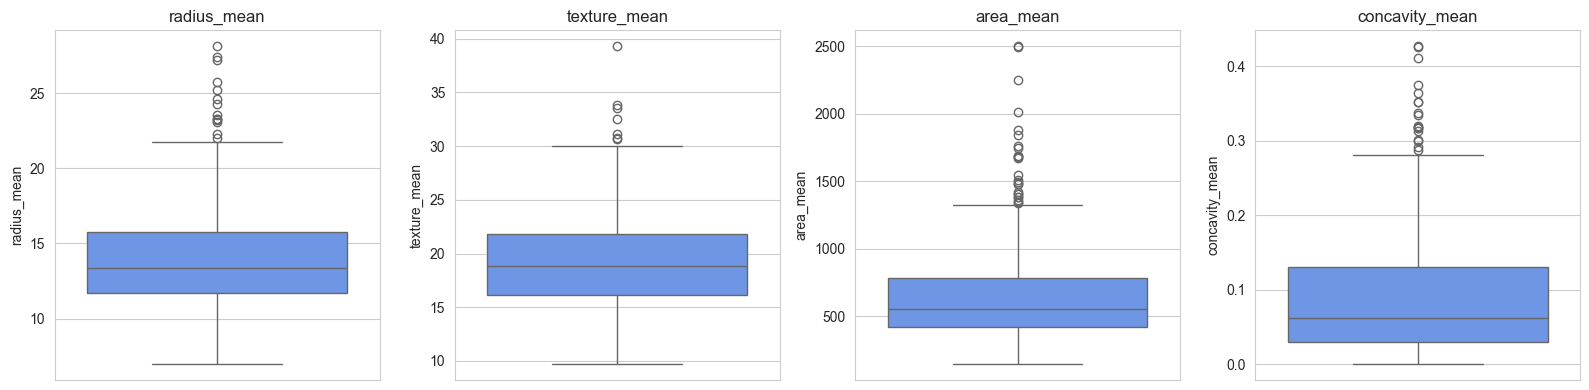

In [79]:
# Visualização de outliers com boxplots (apenas algumas features 'mean' como exemplo)
features_exemplo = ["radius_mean", "texture_mean", "area_mean", "concavity_mean"]

fig, axes = plt.subplots(1, len(features_exemplo), figsize=(16, 4))
for ax, col in zip(axes, features_exemplo):
    sns.boxplot(y=df[col], ax=ax, color="#5B8FF9")
    ax.set_title(col)
plt.tight_layout()
plt.show()


**Observação sobre outliers:** existem alguns pontos fora do intervalo interquartil, o que é esperado em dados médicos (tumores variam bastante em tamanho e forma). Optamos por **não remover** esses outliers, pois eles podem representar casos clínicos reais e relevantes (tumores muito grandes/agressivos), justamente os que o modelo precisa aprender a identificar. A remoção poderia descartar informação valiosa para a classe minoritária (maligno).


## 2. Encoding

A coluna alvo (`diagnosis`) é **categórica** (`M` = Maligno, `B` = Benigno), mas os algoritmos de Machine Learning trabalham apenas com valores numéricos. Precisamos codificá-la.

Como é uma variável **binária**, usamos o `LabelEncoder` (ou um simples `map`), transformando:
- `M` (Maligno) → 1
- `B` (Benigno) → 0

> Não usamos One-Hot Encoding aqui porque a variável já é binária — criar duas colunas seria redundante.


In [80]:
print("Classes originais:", df["diagnosis"].unique())

# Conervetendo a coluna diagnóstico para valores numéricos, onde 0 = benigno e 1 = maligno
df['diagnosis'] = df['diagnosis'].map({'B': 0, 'M': 1})

print(f'Mapeamento: B = 0, M = 1 - Contagem: {df["diagnosis"].value_counts().values}')

Classes originais: ['M' 'B']
Mapeamento: B = 0, M = 1 - Contagem: [357 212]


### 2.1 Balanceamento das classes

Vale observar a proporção entre as classes: se estiverem muito desbalanceadas, métricas como *acurácia* podem enganar, e pode ser necessário usar técnicas como `class_weight`, oversampling (SMOTE) ou métricas como *recall*/*F1-score* focadas na classe minoritária (maligno), que é a mais crítica clinicamente.


Proporção das classes (%):
diagnosis
0    62.74
1    37.26
Name: proportion, dtype: float64


C:\Users\behon\AppData\Local\Temp\ipykernel_68140\1187230262.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="diagnosis", data=df, palette=["#5B8FF9", "#F76E6E"])


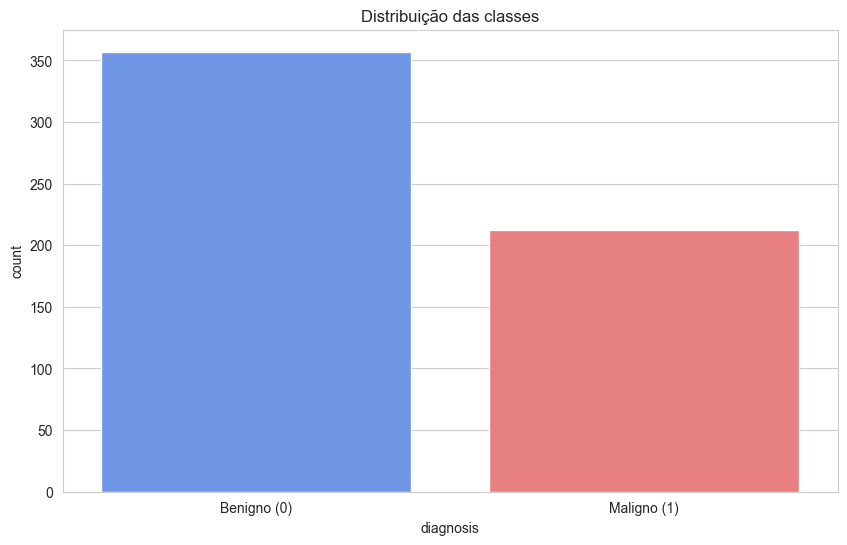

In [81]:
proporcao = df["diagnosis"].value_counts(normalize=True) * 100
print("Proporção das classes (%):")
print(proporcao.round(2))

sns.countplot(x="diagnosis", data=df, palette=["#5B8FF9", "#F76E6E"])
plt.xticks([0, 1], ["Benigno (0)", "Maligno (1)"])
plt.title("Distribuição das classes")
plt.show()


As classes estão moderadamente desbalanceadas (aprox. 63% benigno / 37% maligno). Não é um desbalanceamento extremo, mas é importante ter em mente na hora de avaliar o modelo (usar `stratify` no split, como faremos, e acompanhar métricas como recall/F1 além da acurácia).


## 3. Correlação

Analisar a correlação entre as variáveis ajuda a:
1. **Entender quais features mais se relacionam com o diagnóstico** (correlação com o alvo);
2. **Identificar multicolinearidade** — pares de variáveis muito correlacionadas entre si (ex.: `radius_mean` e `perimeter_mean`, que são geometricamente dependentes) podem ser redundantes e, dependendo do modelo, prejudicar a performance ou dificultar a interpretação.


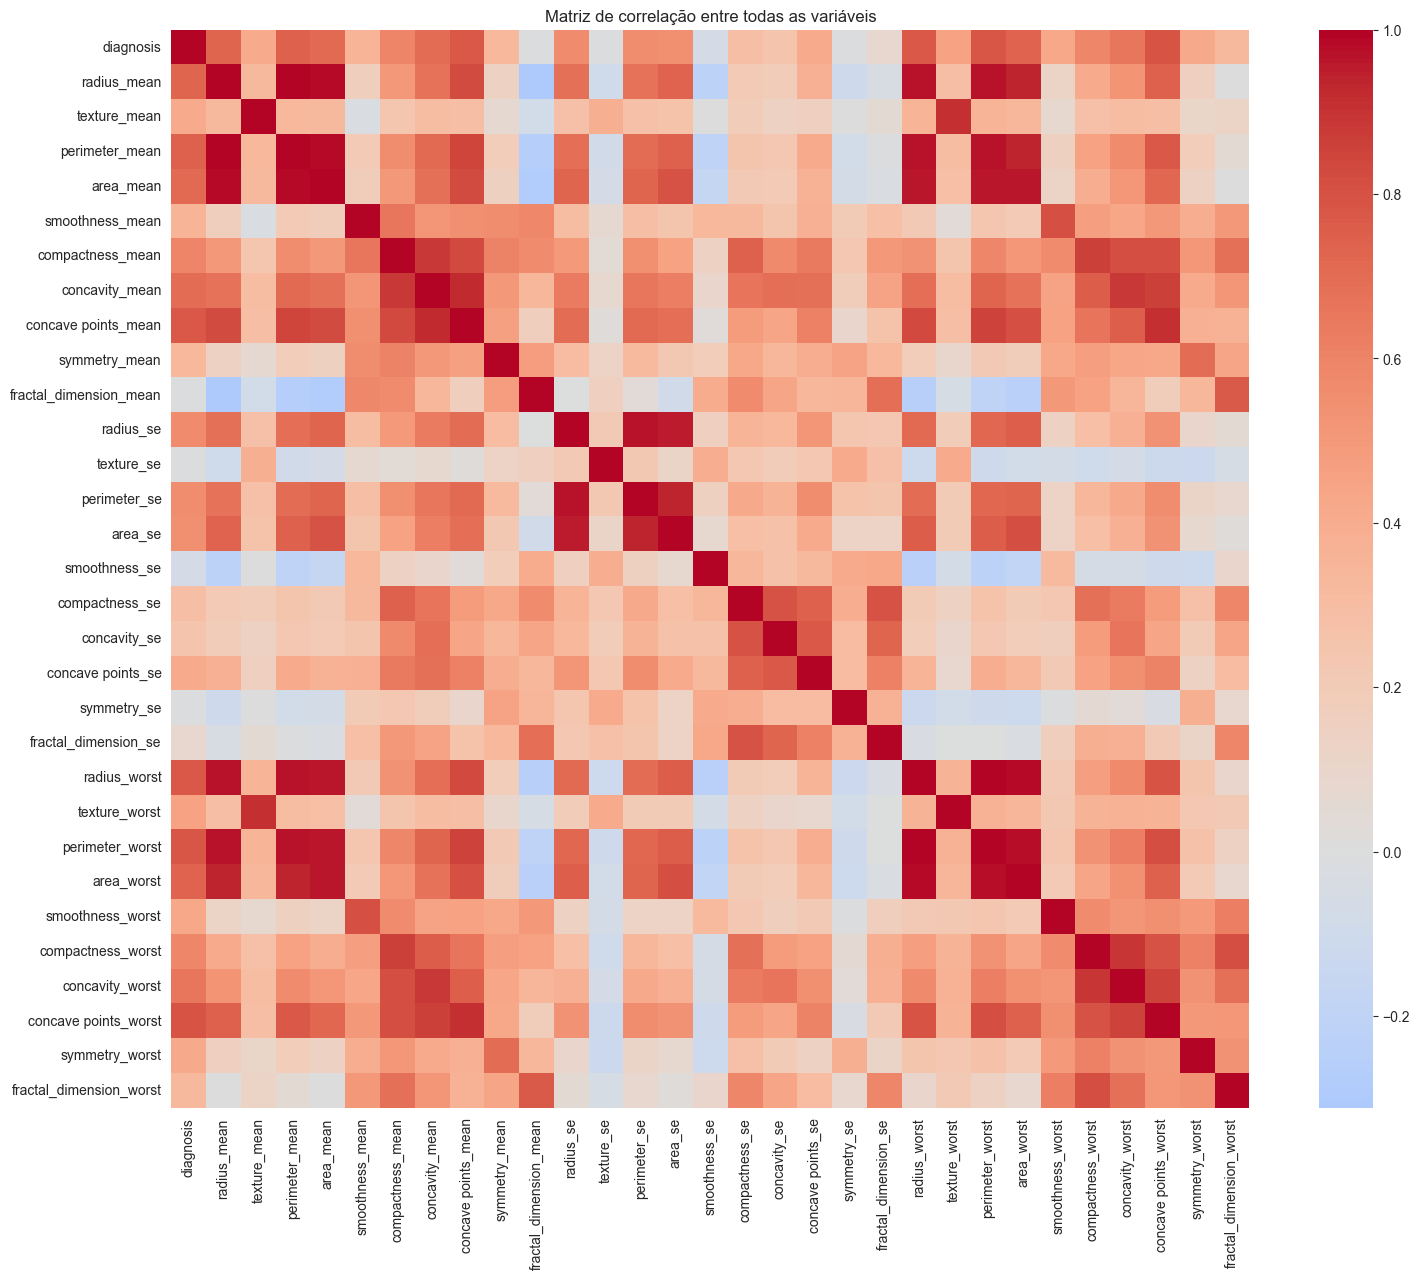

In [82]:
# Matriz de correlação completa
corr_matrix = df.corr()

plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=False, square=True)
plt.title("Matriz de correlação entre todas as variáveis")
plt.show()


C:\Users\behon\AppData\Local\Temp\ipykernel_68140\759794811.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_target.values, y=corr_target.index, palette="coolwarm")


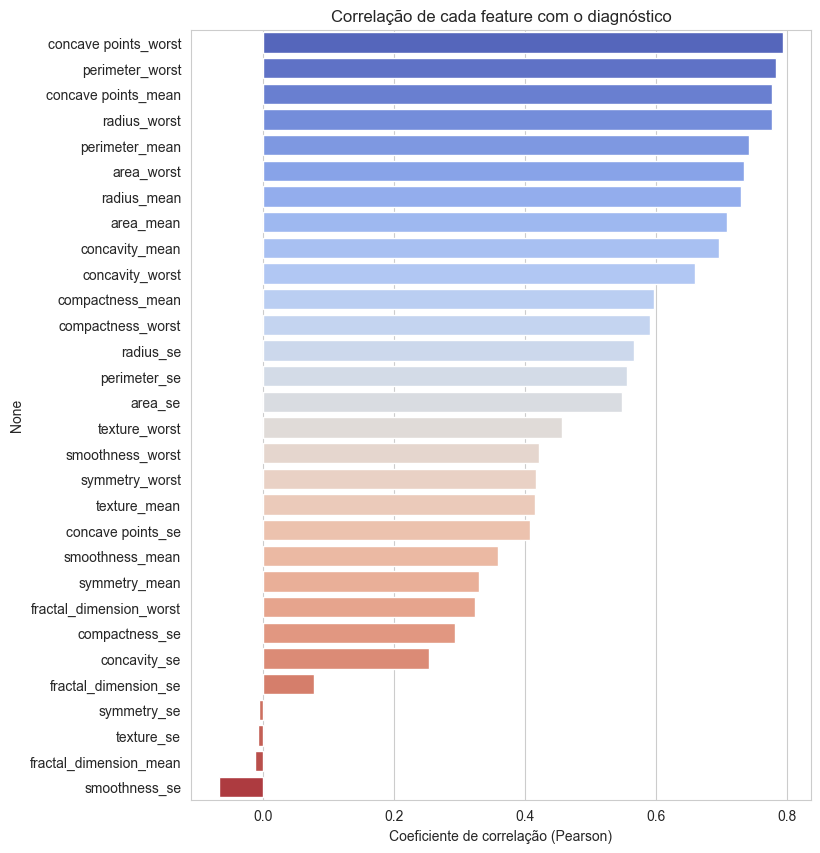

Top 5 features mais correlacionadas (positivamente) com o diagnóstico:
concave points_worst    0.793566
perimeter_worst         0.782914
concave points_mean     0.776614
radius_worst            0.776454
perimeter_mean          0.742636
Name: diagnosis, dtype: float64


In [83]:
# Correlação de cada feature com a variável alvo (diagnosis), ordenada
corr_target = corr_matrix["diagnosis"].drop("diagnosis").sort_values(ascending=False)

plt.figure(figsize=(8, 10))
sns.barplot(x=corr_target.values, y=corr_target.index, palette="coolwarm")
plt.title("Correlação de cada feature com o diagnóstico")
plt.xlabel("Coeficiente de correlação (Pearson)")
plt.show()

print("Top 5 features mais correlacionadas (positivamente) com o diagnóstico:")
print(corr_target.head(5))


### 3.1 Identificando pares de variáveis altamente correlacionadas (multicolinearidade)

Vamos localizar pares de *features* (excluindo o alvo) com correlação absoluta acima de 0.9 — um sinal forte de redundância.


In [84]:
# Matriz de correlação apenas entre as features (sem o alvo)
features_corr = df.drop(columns=["diagnosis"]).corr().abs()

# Pegamos apenas o triângulo superior da matriz para não repetir pares (A,B) e (B,A)
upper_triangle = features_corr.where(np.triu(np.ones(features_corr.shape), k=1).astype(bool))

# Pares com correlação alta (> 0.9)
pares_altamente_correlacionados = (
    upper_triangle.stack()
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2", 0: "correlacao"})
)
pares_altamente_correlacionados = pares_altamente_correlacionados[
    pares_altamente_correlacionados["correlacao"] > 0.9
].sort_values("correlacao", ascending=False)

print(f"Número de pares com correlação > 0.9: {len(pares_altamente_correlacionados)}")
pares_altamente_correlacionados.head(15)


Número de pares com correlação > 0.9: 21


,feature_1,feature_2,correlacao
1,radius_mean,perimeter_mean,0.997855
391,radius_worst,perimeter_worst,0.993708
2,radius_mean,area_mean,0.987357
57,perimeter_mean,area_mean,0.986507
392,radius_worst,area_worst,0.984015
407,perimeter_worst,area_worst,0.977578
246,radius_se,perimeter_se,0.972794
76,perimeter_mean,perimeter_worst,0.970387
19,radius_mean,radius_worst,0.969539
74,perimeter_mean,radius_worst,0.969476


**Observação:** como esperado, medidas como `radius`, `perimeter` e `area` (nas versões `mean`, `se` e `worst`) são fortemente correlacionadas entre si — o que faz sentido geometricamente (raio, perímetro e área de um círculo são todos derivados um do outro).

**Decisão adotada:** neste notebook optamos por **manter todas as features** e deixar a etapa de seleção/redução de dimensionalidade (ex.: remoção manual, PCA, regularização L1/L2) para a fase de modelagem. Isso porque:
- Alguns modelos (árvores, Random Forest, Gradient Boosting) lidam bem com multicolinearidade;
- Remover features aqui, sem saber qual algoritmo será usado, pode descartar informação prematuramente.

Se o modelo escolhido for sensível a multicolinearidade (ex.: Regressão Logística, KNN), recomenda-se revisitar essa lista de pares e remover uma variável de cada par redundante, ou aplicar PCA.


## 4. Split (divisão treino/teste)

Antes de construir o `Pipeline` de transformação, separamos os dados em **treino** e **teste**.

> **Importante:** o split deve ser feito **antes** do escalonamento. Se ajustássemos (`fit`) o scaler com a base inteira, informações estatísticas do conjunto de teste (média, desvio padrão) "vazariam" para o treino — o chamado **data leakage** — inflando artificialmente a performance do modelo.

Usamos `stratify=y` para manter a mesma proporção de classes (benigno/maligno) tanto no treino quanto no teste, já que vimos que as classes são um pouco desbalanceadas.


In [85]:
# Separando features (X) e alvo (y)
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

# Split treino/teste (80% / 20%), mantendo a proporção das classes com stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,   # garante reprodutibilidade
    stratify=y          # mantém a proporção de M/B em treino e teste
)

print(f"Tamanho do treino: {X_train.shape[0]} amostras")
print(f"Tamanho do teste:  {X_test.shape[0]} amostras")
print()
print("Proporcao de classes no treino:")
print(y_train.value_counts(normalize=True).round(3))
print()
print("Proporcao de classes no teste:")
print(y_test.value_counts(normalize=True).round(3))


Tamanho do treino: 455 amostras
Tamanho do teste:  114 amostras

Proporcao de classes no treino:
diagnosis
0    0.626
1    0.374
Name: proportion, dtype: float64

Proporcao de classes no teste:
diagnosis
0    0.632
1    0.368
Name: proportion, dtype: float64


## 5. Escalonamento (Scaling)

Como vimos em `describe()`, as variáveis estão em escalas muito diferentes (ex.: `area_mean` chega à casa das centenas/milhares, enquanto `smoothness_mean` fica entre 0 e 1). Isso é um problema para diversos algoritmos:

- **KNN e SVM**: usam distância entre pontos — variáveis com maior magnitude dominam o cálculo, mesmo que não sejam mais importantes.
- **Regressão Logística e Redes Neurais**: convergem mais rápido e de forma mais estável com dados na mesma escala.
- **Árvores de decisão e Random Forest**: são invariantes à escala, mas escalonar não prejudica.

Usamos o `StandardScaler`, que padroniza cada variável para ter **média 0** e **desvio padrão 1** (z-score)


## 6. Pipeline

Reunimos o pré-processamento em um `Pipeline` do scikit-learn. As vantagens de usar um Pipeline em vez de aplicar as transformações "soltas":

- **Evita vazamento de dados**: o `fit` (cálculo de média/desvio) acontece apenas no treino; o teste (e dados novos) apenas usam `transform`.
- **Reprodutibilidade**: encapsula todas as etapas em um único objeto, fácil de salvar/reutilizar.
- **Integração direta com o modelo**: o restante da equipe pode simplesmente encaixar o classificador (`LogisticRegression`, `RandomForestClassifier`, etc.) como uma etapa final do mesmo Pipeline.


In [86]:
# Construindo o pipeline de pré-processamento
# (aqui incluímos apenas o escalonamento; novas etapas — como seleção de
# features ou PCA — poderiam ser adicionadas como passos extras do Pipeline)
preprocessing_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler())
])

# Ajustando (fit) o pipeline SOMENTE com os dados de treino
X_train_processed = preprocessing_pipeline.fit_transform(X_train)

# Aplicando (transform) a mesma transformação aprendida no teste
X_test_processed = preprocessing_pipeline.transform(X_test)

# Reconstruindo DataFrames (para facilitar inspeção e uso posterior)
X_train_processed = pd.DataFrame(X_train_processed, columns=X_train.columns, index=X_train.index)
X_test_processed = pd.DataFrame(X_test_processed, columns=X_test.columns, index=X_test.index)

print("Antes do escalonamento (treino):")
print(X_train.describe().loc[["mean", "std"]].T.head())
print()
print("Depois do escalonamento (treino):")
print(X_train_processed.describe().loc[["mean", "std"]].T.head())


Antes do escalonamento (treino):
                       mean         std
radius_mean       14.166077    3.579081
texture_mean      19.417692    4.290653
perimeter_mean    92.215868   24.717118
area_mean        659.578242  360.418686
smoothness_mean    0.095993    0.014310

Depois do escalonamento (treino):
                         mean       std
radius_mean     -1.737316e-16  1.001101
texture_mean     3.904081e-16  1.001101
perimeter_mean   4.704418e-16  1.001101
area_mean       -1.171224e-16  1.001101
smoothness_mean  7.242070e-16  1.001101


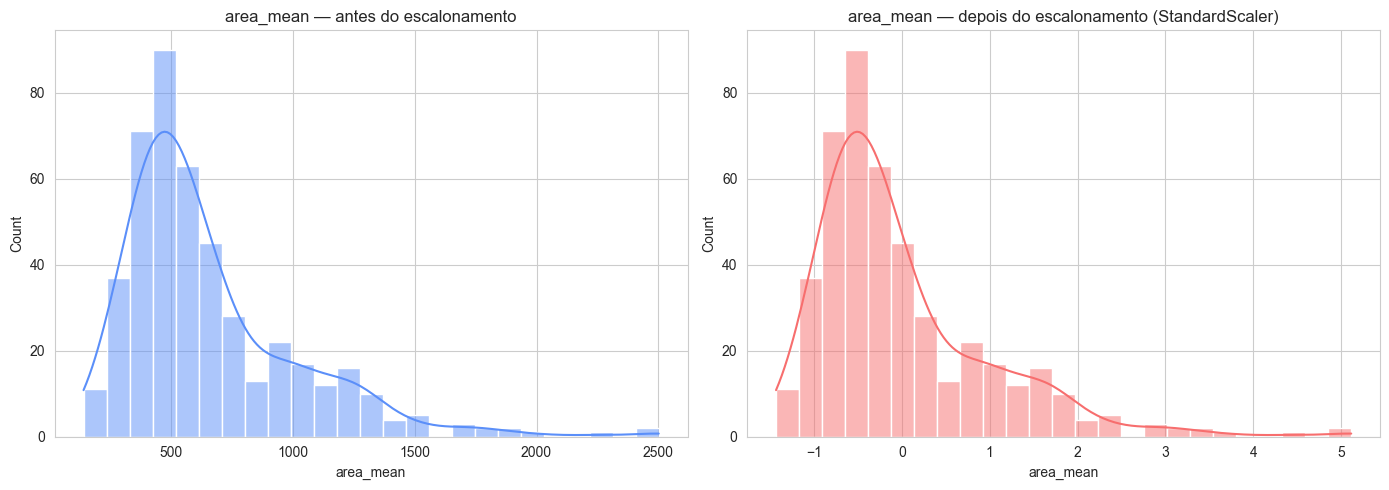

In [87]:
# Comparação visual: distribuição de uma feature antes x depois do escalonamento
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(X_train["area_mean"], kde=True, ax=axes[0], color="#5B8FF9")
axes[0].set_title("area_mean — antes do escalonamento")

sns.histplot(X_train_processed["area_mean"], kde=True, ax=axes[1], color="#F76E6E")
axes[1].set_title("area_mean — depois do escalonamento (StandardScaler)")

plt.tight_layout()
plt.show()


Note que o **formato** da distribuição não muda — apenas a escala (eixo X). Isso é esperado: o `StandardScaler` não altera a forma da distribuição, apenas centraliza (média 0) e normaliza a variância (desvio padrão 1).


## Resumo final

Ao final deste pré-processamento, temos:

| Item | Descrição |
|---|---|
| `X_train_processed` | Features de treino, limpas, codificadas e escalonadas |
| `X_test_processed`  | Features de teste, transformadas com os parâmetros aprendidos no treino |
| `y_train` / `y_test` | Rótulos (0 = Benigno, 1 = Maligno) |
| `preprocessing_pipeline` | Pipeline ajustado, pronto para ser reutilizado em novos dados ou acoplado a um classificador |

**Próximos passos sugeridos para a equipe:**
1. Acoplar um classificador (ex.: `LogisticRegression`, `RandomForestClassifier`, `SVC`) como etapa final do `preprocessing_pipeline`;
2. Avaliar o modelo com métricas adequadas ao contexto médico — **recall** e **F1-score** da classe "Maligno" tendem a ser mais importantes que a acurácia pura, pois um falso negativo (dizer que um tumor maligno é benigno) é muito mais grave que um falso positivo;
3. Se necessário, revisitar a etapa de correlação para tratar a multicolinearidade identificada (remoção de features redundantes ou PCA), dependendo do algoritmo escolhido.


In [88]:
X_train_processed.head()


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
10,0.518559,0.891826,0.424632,0.383925,-0.974744,-0.689772,-0.688586,-0.398175,-1.039155,-0.825056,-0.109318,-0.055976,-0.210096,-0.015913,-1.005184,-0.911942,-0.662816,-0.652561,-0.701889,-0.275394,0.579798,1.313242,0.466908,0.445983,-0.596155,-0.634722,-0.610227,-0.235744,0.054566,0.021837
170,-0.516364,-1.639710,-0.541349,-0.542961,0.476219,-0.631834,-0.604281,-0.303075,0.521543,-0.454523,-0.604378,-1.001046,-0.585429,-0.493454,0.403212,-0.768173,-0.479187,0.114508,-0.142951,-0.577398,-0.582459,-1.690291,-0.611934,-0.587014,0.273582,-0.814844,-0.712666,-0.323208,-0.137576,-0.904402
407,-0.368118,0.455515,-0.388250,-0.402970,-1.432979,-0.383927,-0.342175,-0.765459,-0.850857,-0.226171,0.303980,1.051501,-0.169545,-0.000809,-0.310104,1.106330,0.622585,0.273685,0.754483,1.508105,-0.398622,0.181977,-0.475431,-0.420778,-1.622785,-0.391399,-0.431313,-0.890825,-0.675893,-0.144016
430,0.205285,0.726168,0.400330,0.070612,0.243253,2.203585,2.256094,1.213233,0.818474,0.899791,-0.545730,-0.621677,0.261427,-0.353585,0.024460,2.090728,1.490561,1.695127,-0.654909,0.767548,-0.000309,0.274191,0.513776,-0.099482,0.418538,2.865970,2.958619,1.977064,-0.075646,1.728848
27,1.243005,0.194195,1.210377,1.206652,-0.111442,0.051348,0.732962,0.713767,-0.427187,-0.822184,1.523863,1.143941,1.282748,1.081313,1.351845,0.107731,0.592927,1.180988,0.301550,0.171527,1.012835,0.223144,0.938517,0.880910,0.073201,-0.277006,0.327775,0.501859,-0.909322,-0.546249
